# Downstream Analysis Prep

In [7]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import os
import tifffile

import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Funs

In [8]:
def summarise_cellmd(mask):
    from scipy import ndimage
    from skimage.segmentation import find_boundaries
    boundaries = find_boundaries(mask)
    cell_ids = np.unique(mask)[1:]
    areas = ndimage.sum(np.ones_like(mask), mask, cell_ids)
    perims = ndimage.sum(boundaries, mask, cell_ids)
    centroids = ndimage.center_of_mass(np.ones_like(mask), mask, cell_ids)
    y_coords = [centroid[0] for centroid in centroids]
    x_coords = [centroid[1] for centroid in centroids]
    return pd.DataFrame({'area': areas, 'perim': perims, 'x':x_coords, 'y':y_coords}, index=cell_ids)


def img_map(img,figsize=(3,3),cmap='viridis',title=None, origin='lower',labels=False,cbar=False,save=None):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(img, cmap=cmap, origin=origin)
    ax.set_title(title)
    if not labels:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    if cbar:
        plt.colorbar(im, ax=ax)
    if save is not None:
        plt.savefig(save, dpi=300, bbox_inches='tight', transparent=False) 
    plt.show()
    
def shuffle_mask_ids(mask):
    # Get unique non-zero values
    unique_ids = np.unique(mask[mask != 0])
    
    # Create shuffled mapping
    shuffled_ids = unique_ids.copy()
    np.random.shuffle(shuffled_ids)
    
    # Create lookup table for efficient remapping
    # Index by old ID, get new ID
    max_id = mask.max()
    lookup = np.arange(max_id + 1)
    lookup[unique_ids] = shuffled_ids
    
    # Apply mapping
    return lookup[mask]

def mask2shapely(masks_in):
    from shapely.geometry import Polygon
    import geopandas as gpd
    from skimage import measure
    import numpy as np
    
    ids = []
    geometries = []

    for i in np.unique(masks_in)[1:]:
        binary_mask = (masks_in == i).astype(np.uint8)
        
        # Find contours using scikit-image
        contours = measure.find_contours(binary_mask, 0.5)
        
        # If multiple contours (disconnected pixels), take the longest one
        if len(contours) > 1:
            longest_contour = max(contours, key=len)
            # Convert from (row, col) to (x, y) coordinates
            coords = longest_contour[:, [1, 0]]
            if len(coords) > 3:
                geometries.append(Polygon(coords))
                ids.append(i)
        else:
            if len(contours) > 0 and len(contours[0]) > 3:
                # Convert from (row, col) to (x, y) coordinates
                coords = contours[0][:, [1, 0]]
                geometries.append(Polygon(coords))
                ids.append(i)
    
    gdf = gpd.GeoDataFrame({'id': ids, 'geometry': geometries}, crs='EPSG:4326')
    gdf = gdf[gdf['id'] != 0]
    gdf['x'] = gdf.geometry.centroid.x
    gdf['y'] = gdf.geometry.centroid.y   

    return gdf

def mask_map(img,mask, figsize=(4,4),fs=None, linewidth=0.75, title=None, origin='upper', cmap='viridis', labels=False):
    if fs is not None:
        figsize=fs


    gdf = mask2shapely(mask)
    
    fig,ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap=cmap, interpolation='none', origin=origin)
    gdf.boundary.plot(aspect=1, ax=ax, color='white',linewidth=linewidth)
    ax.set_title(title)
    if not labels:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

def import_canvas_shapes(loc):
    import json
    import re
    import geopandas as gpd
    from shapely.geometry import Polygon, box

    with open(loc) as f:
        data = json.load(f)
    
    geometries = []
    for shape_data in data['shapes']:
        if shape_data['type'] == 'rect':
            # Handle rectangles
            poly = box(shape_data['x0'], shape_data['y0'], 
                      shape_data['x1'], shape_data['y1'])
            geometries.append(poly)
            
        elif shape_data['type'] == 'path':
            # Handle paths
            path_str = shape_data['path']
            numbers = re.findall(r'[-\d.]+', path_str)
            coords = [(float(numbers[i]), float(numbers[i+1])) 
                     for i in range(0, len(numbers), 2)]
            
            if len(coords) >= 3:
                poly = Polygon(coords)
                geometries.append(poly)

    return gpd.GeoDataFrame({'geometry': geometries}, crs=None)

def cell_in_shape(x, y, gate_polygon):
    import geopandas as gpd
    points = gpd.points_from_xy(x, y)
    inside = points.within(gate_polygon)

    return inside  

def merge_selected_objects(mask, ids_to_merge):
    from scipy import ndimage
    merged_mask = mask.copy()
    #binary mask of selected objects
    selected_binary = np.isin(mask, ids_to_merge)
    #connected components among selected
    labeled, num_features = ndimage.label(selected_binary)
    #get max ID in original
    max_id = mask.max()
    #assign new unique IDs to each cluster
    new_ids = []
    for cluster_id in range(1, num_features + 1):
        cluster_coords = labeled == cluster_id
        new_id = max_id + cluster_id
        merged_mask[cluster_coords] = new_id
        new_ids.append(new_id)
    
    return merged_mask,new_ids

### Prep - MK correction, gate annotation

In [9]:
obs = pd.read_csv('/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/v2_pheno-labels_update3.csv',index_col=0)

In [36]:
obs.lineage.isna().sum()

0

In [30]:
obs[obs['lineage']!='Adipocyte'].shape[0]

1384630

In [65]:
obs['lineage'].value_counts()/obs.shape[0]*100

lineage
Myeloid      40.379959
Lin-         30.313233
Myeloma       7.718544
T             4.891194
NK            3.741572
EC            3.460639
B-T           3.354606
MKs           3.116937
Adipocyte     1.795251
Bcell         0.679177
Artifact      0.548888
Name: count, dtype: float64

In [ ]:
obs_updated = {}

from tqdm import tqdm

#for sample_id in tqdm(obs.sample_id.unique()):
for sample_id in (obs.sample_id.unique()):

    #Skip ungated samples
    if len(os.listdir(f"/mnt/disks/data/imc/CART_cohort/in/sample_gating/{sample_id}"))==0:
        continue
    #think removed this one
    if sample_id=='ROI001_31479_ROI_2':
        continue
        
    # import
    obs_sample = obs[obs.sample_id==sample_id]
    mask = tifffile.imread(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/mask_V1withAdipo.tif')
    #Tissue gating
    gate = import_canvas_shapes(f'/mnt/disks/data/imc/CART_cohort/in/sample_gating/{sample_id}/canvas_shapes.json')
    gate['geometry'] = gate.geometry.buffer(0)
    
    #MK correction
    MK_ids = obs_sample[obs_sample.lineage=='MKs'].Cell_ID.tolist()
    mask_v2,new_ids = merge_selected_objects(mask,MK_ids)

    #save new mask
    tifffile.imwrite(f'/mnt/disks/data/imc/CART_cohort/out/sample_data/{sample_id}/segmentation_masks/mask_V1withAdipo_MKv2.tif', mask_v2)
    
    #update obs
    obs_sample_MKv2 = pd.concat([
        obs_sample[obs_sample.lineage!='MKs'],
        pd.DataFrame({'sample_id':sample_id,'Cell_ID':new_ids,'lineage':'MKs','ph':'MKs','Ki67_pos':False})
    ])
    
    #mask_v2 md
    mask_v2_md = summarise_cellmd(mask_v2)

    #id gated cells
    cellmd_pre = mask_v2_md
    gated_cells = cellmd_pre[cell_in_shape(cellmd_pre.x, cellmd_pre.y, gate.geometry.unary_union)].index
    obs_sample_MKv2['gated'] = obs_sample_MKv2.Cell_ID.isin(gated_cells)
   
    # Attach area/coords
    obs_sample_MKv2 = obs_sample_MKv2.merge(
        mask_v2_md.reset_index().rename({'index':'Cell_ID'},axis=1), how='left'
    )
    print(sample_id + '\t' + str(obs_sample.shape[0] - obs_sample_MKv2.shape[0]))
    
    obs_updated[sample_id] = obs_sample_MKv2



In [12]:
obs_v2 = pd.concat(obs_updated.values())
obs_v2.head(1)

,sample_id,Cell_ID,lineage,ph,Ki67_pos,gated,area,perim,x,y
0,BS-22-A73610_002,1,Myeloid,Mye_other,False,True,26.0,19.0,694.923077,5.153846


### Update MM/NK assignment

In [14]:
# High NK most likely MM
mrn_samples = {
    pt1:['ROI002_46300_ROI_1'], #high NK%, CD56+MM
    pt2:["BS-22-T68482_002","BS-23-M07987_002","BS-23-M07987_003"],
    pt3:["BS-22-F63589_002"],
    pt4:["ROI001_44243_ROI_1"], #"also CD56 pos, has 9%MM and 18% NK.. NKs here also MM, infiltration at 40%"
    pt5:["ROI002_40787_ROI_1"],
    pt6:["ROI001_49270_ROI_1"],
    pt7:["BS-24-M23337_002"],
    pt8:["ROI001_29469_ROI_1"],
    pt9:["BS-24-T02447_002"],
    pt10:["ROI002_47580_ROI_1","ROI001_47580_ROI_2"],
    pt11:["ROI002_35480_ROI_1"],
    pt12:["BS-23-N56046_002"]
}

In [15]:
# Import normalized/corrected expression

adata = sc.read("/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/full_data-no_uns.h5ad")

adata = adata[adata.obs.major_cell_type!='Adipocyte',]

from inmoose.pycombat import pycombat_norm

adata.obs['log1p_totalsignal'] = np.log1p(adata.X.sum(axis=1))
adata.layers['Xpc_totsig_log1p_combat'] = pycombat_norm(
    np.log1p(pd.DataFrame(pd.DataFrame(adata.X).fillna(0).values.T+1).div(adata.obs['log1p_totalsignal'].tolist(), axis=1)),
    adata.obs.cohort).T

v1_exp = sc.get.obs_df(adata, ['sample_id','cohort','Cell_ID','log1p_totalsignal','CD56','CD138'], layer='Xpc_totsig_log1p_combat')

del adata
import gc
gc.collect()

101

In [9]:
#tmp=v1_exp.copy()

In [16]:
v1_exp = v1_exp.merge(obs_v2[['sample_id','Cell_ID','lineage']], how='left')
v1_exp = v1_exp.loc[~v1_exp.CD56.isna()]

In [17]:
v1_exp.head(1)

,sample_id,cohort,Cell_ID,log1p_totalsignal,CD56,CD138,lineage
0,ROI001_50286_ROI_1,og,1,4.369597,0.597662,0.336264,EC


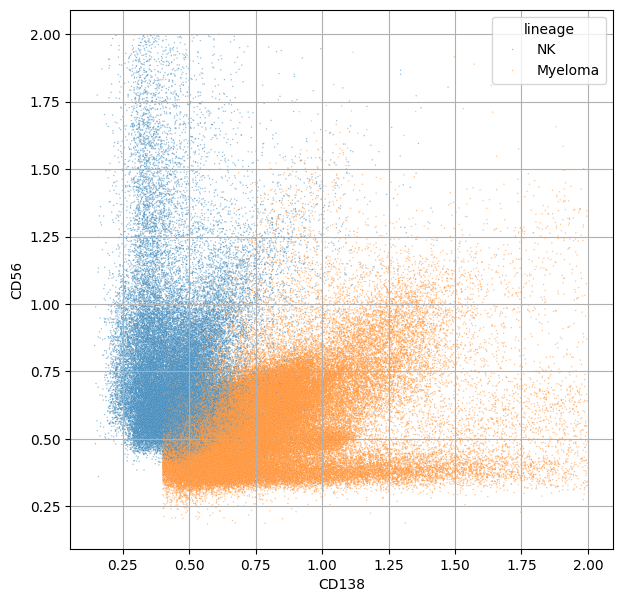

In [13]:
v1_exp_pl = v1_exp[v1_exp.lineage.isin(['NK','Myeloma'])]
v1_exp_pl = v1_exp_pl[ (v1_exp_pl.CD56<2)&(v1_exp_pl.CD138<2)]

fig,ax=plt.subplots(figsize=(7,7))
sns.scatterplot(v1_exp_pl, x='CD138', y='CD56', hue='lineage', alpha=0.5, s=1, ax=ax)
plt.grid(True)
plt.show()

In [19]:
# Get the geometry for each gate (line)

mrn__samples_coords = {
    pt1:[['ROI002_46300_ROI_1'],[0.2,0.8], [0.5,1.5]], 
    pt2:[["BS-22-T68482_002","BS-23-M07987_002","BS-23-M07987_003"],[0.3,0.6], [0.6,1.5]],
    pt3:[["BS-22-F63589_002"],[0.2,0.5], [0.5,1.5]],
    pt4:[["ROI001_44243_ROI_1"],[0.4,0.75], [0.5,1.5]], 
    pt5:[["ROI002_40787_ROI_1"],[0.4,0.75], [0.5,1.5]],
    pt6:[["ROI001_49270_ROI_1"],[0.3,0.5], [0.5,0.7]],
    pt7:[["BS-24-M23337_002"],[0.3,0.6], [0.5,0.9]],
    pt8:[["ROI001_29469_ROI_1"],[0.4,0.5], [0.5,0.7]],
    pt9:[["BS-24-T02447_002"],[0.3,0.7], [0.5,1.7]],
    pt10:[["ROI002_47580_ROI_1","ROI001_47580_ROI_2"],[0.3,0.7], [0.5,1.5]],
    pt11:[["ROI002_35480_ROI_1"],[0.3,0.5], [0.4,0.7]],
    pt12:[["BS-23-N56046_002"],[0.3,0.7], [0.3,0.7]]
}

In [ ]:
loc_ = "/mnt/disks/data/imc/CART_cohort/out/final_figures/"
i=1

v1_exp_pl = v1_exp[v1_exp.lineage.isin(['NK','Myeloma'])]
v1_exp_pl = v1_exp_pl[ (v1_exp_pl.CD56<2)&(v1_exp_pl.CD138<2)]

for mrn,values_ in mrn__samples_coords.items():
    samples,xs,ys=values_
    
    v1_exp_pl['pl'] = v1_exp_pl.sample_id.isin(samples)
    
    fig,ax=plt.subplots(figsize=(5,5))
    plt.xticks([i/10 for i in range(-1,30,2)])
    plt.yticks([i/10 for i in range(-1,30,2)])
    plt.grid(True)
    sns.scatterplot(v1_exp_pl[~v1_exp_pl.pl], x='CD138', y='CD56', color='darkgrey', alpha=0.5, s=0.1, ax=ax)
    sns.scatterplot(v1_exp_pl[v1_exp_pl.pl], x='CD138', y='CD56', color='red', alpha=0.75, s=1, ax=ax)
    ax.set_title(str(mrn)+' '+str(i))
    #plt.plot(xs, ys, 'b-', linewidth=1)
    ax.plot(xs, ys, 'b-', linewidth=1)
    plt.savefig(loc_+f'Fig_S1G-{str(i)}.pdf', dpi=300, bbox_inches='tight', transparent=False)
    i+=1
    plt.show()


In [16]:
v1_exp['lineage_updated'] = v1_exp['lineage'].tolist()

for mrn,values_ in mrn__samples_coords.items():
    samples,xs,ys=values_
    x1,x2=xs
    y1,y2=ys

    v1_exp_sub = v1_exp.copy()
    v1_exp_sub = v1_exp_sub[v1_exp_sub.lineage.isin(['NK','Myeloma'])]
    v1_exp_sub = v1_exp_sub[v1_exp_sub.sample_id.isin(samples)]

    for i_,r_ in v1_exp_sub.iterrows():
        res = (x2 - x1) * (r_['CD56'] - y1) - (y2 - y1) * (r_['CD138'] - x1)
        if res > 0:
            v1_exp.loc[i_,'lineage_updated']='NK'
        else:
            v1_exp.loc[i_,'lineage_updated']='Myeloma'

In [58]:
obs_v3 = obs_v2.merge(v1_exp_sub[['sample_id','Cell_ID','lineage_updated']], how='left')
obs_v3['lineage'] = obs_v3['lineage_updated'].fillna(obs_v3['lineage'])
obs_v3['ph'] = obs_v3['lineage_updated'].fillna(obs_v3['ph'])
obs_v3 = obs_v3.drop('lineage_updated',axis=1)

### Reverse M1/M2 (checked, `2_pheno-labels_update3.csv` is reversed)

In [62]:
obs_v4 = obs_v3.copy()
obs_v4.ph = obs_v3.ph.replace({"Mac_M1":"Mac_M2","Mac_M2":'Mac_M1'})
obs_v4.to_csv('../../obs_v4.csv')

### % Ki-67 & PD-L1 +ve

In [29]:
# Import normalized/corrected expression

adata = sc.read("/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/full_data-no_uns.h5ad")

adata = adata[adata.obs.major_cell_type!='Adipocyte',]

from inmoose.pycombat import pycombat_norm

adata.obs['log1p_totalsignal'] = np.log1p(adata.X.sum(axis=1))
adata.layers['Xpc_totsig_log1p_combat'] = pycombat_norm(
    np.log1p(pd.DataFrame(pd.DataFrame(adata.X).fillna(0).values.T+1).div(adata.obs['log1p_totalsignal'].tolist(), axis=1)),
    adata.obs.cohort).T

v1_exp = sc.get.obs_df(adata, ['sample_id','cohort','Cell_ID','log1p_totalsignal','Ki-67','PD-L1'], layer='Xpc_totsig_log1p_combat')

del adata
import gc
gc.collect()

821

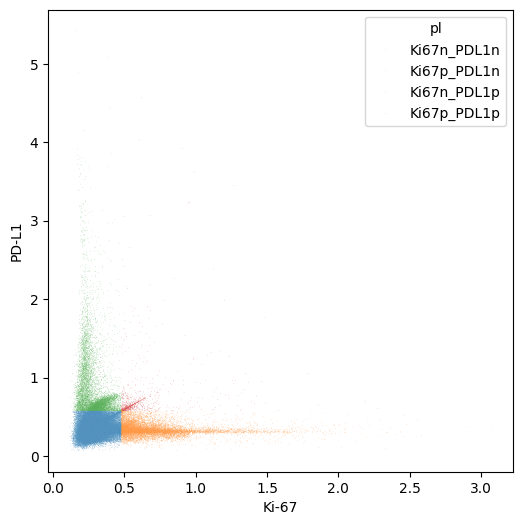

In [37]:
v1_exp['Ki67is'] = np.where(v1_exp['Ki-67']>(np.mean(v1_exp['Ki-67'])+np.std(v1_exp['Ki-67'])),'Ki67p','Ki67n')
v1_exp['PDL1is'] = np.where(v1_exp['PD-L1']>np.mean(v1_exp['PD-L1']+np.std(v1_exp['PD-L1'])),'PDL1p','PDL1n')
v1_exp['pl'] = v1_exp['Ki67is'].astype(str)+'_'+v1_exp['PDL1is'].astype(str)

fig,ax=plt.subplots(figsize=(6,6))
sns.scatterplot(v1_exp.sample(frac=0.1), x='Ki-67', y='PD-L1', hue='pl', s=0.1, ax=ax)
plt.show()

In [50]:
obs_v5 = obs_v4.merge(v1_exp[['sample_id','Cell_ID','Ki67is','PDL1is']], how='left')

### Check cluster % +/- gating

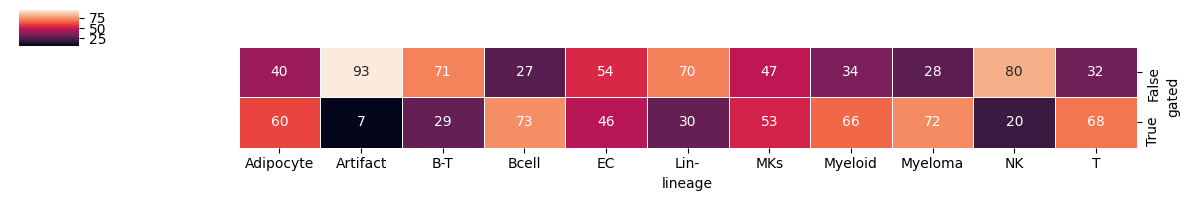

In [63]:
df = np.round(pd.crosstab(obs_v4.gated, obs_v4.lineage).div(obs_v4.lineage.value_counts(),axis=1)*100,4)
sns.clustermap(df, z_score=None, figsize=(12,2), xticklabels=True, yticklabels=True, annot=True,
               col_cluster=False, row_cluster=False, linewidths=0.5, linecolor='white')
plt.show()

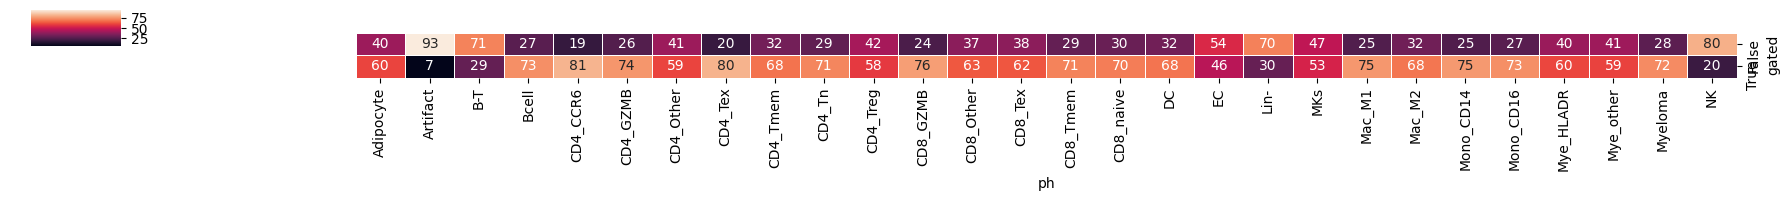

In [64]:
df = np.round(pd.crosstab(obs_v4.gated, obs_v4.ph).div(obs_v4.ph.value_counts(),axis=1)*100,4)
sns.clustermap(df, z_score=None, figsize=(18,2), xticklabels=True, yticklabels=True, annot=True,
               col_cluster=False, row_cluster=False, linewidths=0.5, linecolor='white')
plt.show()

### Save

In [51]:
###obs_v5.to_csv('/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/obs_v5.csv',index=False)
obs_v5 = pd.read_csv('/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/obs_v5.csv')
obs_v5.head(1)

,sample_id,Cell_ID,lineage,ph,Ki67_pos,gated,area,perim,x,y,Ki67is,PDL1is
0,BS-22-A73610_002,1,Myeloid,Mye_other,False,True,26.0,19.0,694.923077,5.153846,Ki67n,PDL1n


In [147]:
obs_v5['sample_id'].drop_duplicates().reset_index().merge(
        pd.read_csv('/mnt/disks/data/imc/CART_cohort/in/sample_id-clinical.csv')
).drop('index',axis=1).to_csv('/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/final_selected_ROI.csv',index=False)

### Export: MKv2 +; tissue gated +/-; Lin- in/out;
* and no Artifact/B-T

#### Prep

In [5]:
obs_v5 = pd.read_csv('/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/obs_v5.csv')
obs_out = obs_v5.copy()

In [6]:
def calc_pct_table(df_in, clus):
    
    clus_ids = df_in[clus].unique().tolist()
    
    df = df_in[['sample_id',clus]].value_counts().reset_index()\
        .merge(df_in[['sample_id']].value_counts().reset_index().rename({'count':'total'},axis=1))
    
    df = df.merge(
        pd.read_csv('/mnt/disks/data/imc/CART_cohort/in/sample_id-clinical.csv')
    ).drop('sample_id',axis=1).groupby(['MRN','Timepoint',clus]).sum().reset_index()
    
    df['pct'] = df['count']/df['total']
    df = df.pivot(index=['MRN','Timepoint'],columns=clus, values='pct').fillna(0).reset_index()
    
    df = df[ df[clus_ids].sum(axis=1)>0 ]

    df[clus_ids] = df[clus_ids]*100
    
    return df

#### Lineage

In [55]:
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'lineage'
clus_remove = ['Artifact','B-T']
sample_remove = ['BS-21-F34416']

In [56]:
# MKv2+; tissue gated+; Lin- in
df = obs_out
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
calc_pct_table(df,clus).to_csv(f"{save_dir}pct-major-MKv2_gatedGood_linNegIn.csv",index=0)

# MKv2+; tissue gated+; Lin- out
df = obs_out
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df[clus]!='Lin-']
df = df[df.gated==True]
calc_pct_table(df,clus).to_csv(f"{save_dir}pct-major-MKv2_gatedGood_linNegOut.csv",index=0)

# MKv2+; tissue gated-; Lin- in
df = obs_out
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
calc_pct_table(df,clus).to_csv(f"{save_dir}pct-major-MKv2_gatedAll_linNegIn.csv",index=0)

# MKv2+; tissue gated-; Lin- in
df = obs_out
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df[clus]!='Lin-']
calc_pct_table(df,clus).to_csv(f"{save_dir}pct-major-MKv2_gatedAll_linNegOut.csv",index=0)

#### Phenotype

In [57]:
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'ph'
clus_remove = ['Artifact','B-T']
sample_remove = ['BS-21-F34416']

In [58]:
# MKv2+; tissue gated+; Lin- in
df = obs_out
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
calc_pct_table(df,clus).to_csv(f"{save_dir}pct-minor-MKv2_gatedGood_linNegIn.csv",index=0)

# MKv2+; tissue gated+; Lin- out
df = obs_out
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df[clus]!='Lin-']
df = df[df.gated==True]
calc_pct_table(df,clus).to_csv(f"{save_dir}pct-minor-MKv2_gatedGood_linNegOut.csv",index=0)

# MKv2+; tissue gated-; Lin- in
df = obs_out
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
calc_pct_table(df,clus).to_csv(f"{save_dir}pct-minor-MKv2_gatedAll_linNegIn.csv",index=0)

# MKv2+; tissue gated-; Lin- in
df = obs_out
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df[clus]!='Lin-']
calc_pct_table(df,clus).to_csv(f"{save_dir}pct-minor-MKv2_gatedAll_linNegOut.csv",index=0)

#### CD4 % CD4

In [102]:
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'ph'
clus_select = ['CD4_CCR6','CD4_GZMB','CD4_Other','CD4_Tex','CD4_Tmem','CD4_Tn','CD4_Treg']
sample_remove = ['BS-21-F34416']

In [103]:
# MKv2+; tissue gated+
df = obs_out
df = df[df[clus].isin(clus_select)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
calc_pct_table(df,clus).to_csv(f"{save_dir}pctCD4-MKv2_gatedGood.csv",index=0)

#### CD8 % CD8

In [104]:
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'ph'
clus_select = ['CD8_GZMB','CD8_Other','CD8_Tex','CD8_Tmem','CD8_naive',]
sample_remove = ['BS-21-F34416']

In [105]:
# MKv2+; tissue gated+
df = obs_out
df = df[df[clus].isin(clus_select)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
calc_pct_table(df,clus).to_csv(f"{save_dir}pctCD8-MKv2_gatedGood.csv",index=0)

#### Mye % Mye

In [106]:
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'ph'
clus_select = ['DC','Mac_M1','Mac_M2','Mono_CD14','Mono_CD16','Mye_HLADR','Mye_other']
sample_remove = ['BS-21-F34416']

In [107]:
# MKv2+; tissue gated+
df = obs_out
df = df[df[clus].isin(clus_select)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
calc_pct_table(df,clus).to_csv(f"{save_dir}pctMye-MKv2_gatedGood.csv",index=0)

#### % Ki67 and PD-L1 +

In [109]:
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'lineage'
m = 'Ki67'
clus_select = ['Myeloma']
clus_remove = ['Artifact','B-T']
sample_remove = ['BS-21-F34416']

In [110]:
df = obs_out
df = df[df[clus].isin(clus_select)]
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]

calc_pct_table(df,m+'is')[['MRN','Timepoint',m+'p']].to_csv(f"{save_dir}{m}p_pctMM-MKv2_gatedGood.csv",index=0)

In [111]:
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'lineage'
m = 'PDL1'
clus_select = ['Myeloma']
clus_remove = ['Artifact','B-T']
sample_remove = ['BS-21-F34416']

In [112]:
df = obs_out
df = df[df[clus].isin(clus_select)]
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]

calc_pct_table(df,m+'is')[['MRN','Timepoint',m+'p']].to_csv(f"{save_dir}{m}p_pctMM-MKv2_gatedGood.csv",index=0)

#### Combine into large table

In [10]:
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
cols_ignore = ['MRN','Timepoint']
dict_ = {
    "pctMajor":f"{save_dir}pct-major-MKv2_gatedGood_linNegIn.csv",
    "pctMinor":f"{save_dir}pct-minor-MKv2_gatedGood_linNegIn.csv",
    "pctCD4":f"{save_dir}pctCD4-MKv2_gatedGood.csv",
    "pctCD8":f"{save_dir}pctCD8-MKv2_gatedGood.csv",
    "pctMye":f"{save_dir}pctMye-MKv2_gatedGood.csv",
    "pctMM":f"{save_dir}Ki67p_pctMM-MKv2_gatedGood.csv",
    "pctMM_":f"{save_dir}PDL1p_pctMM-MKv2_gatedGood.csv"
}

In [11]:
out = []
for suffix,loc in dict_.items():
    out.append( pd.read_csv(loc).rename(columns=lambda col: col+'_'+suffix if col not in cols_ignore else col) )    

In [12]:
from functools import reduce
merged_df = reduce(lambda left, right: pd.merge(left, right, how='left', on=['MRN','Timepoint']), out).fillna(0)

In [18]:
merged_df.to_csv(f"{save_dir}abundances_merged.csv",index=0)

#### % Ki-67/PD-L1+ among all cells

In [38]:
# Ki67, bslTP

cn_id = "bslTP_linNegOut_15clus"
cn_cells_data = pd.read_csv(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/cn_data/{cn_id}-cells_data.csv')
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'ph'
m = 'Ki67'
clus_remove = ['Artifact','B-T','Adipocyte']
sample_remove = ['BS-21-F34416']

df = cn_cells_data
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
#CN__ph
df['CN__ph'] = df['cn_labels'].astype(str)+'__'+df[clus].astype(str)
clus = 'CN__ph'

df_in = df
clus_ids = df_in[clus].unique().tolist()
df = df_in[['sample_id',clus]].value_counts().reset_index()\
    .merge(df_in[['sample_id']].value_counts().reset_index().rename({'count':'total'},axis=1))
df = df.merge(
    pd.read_csv('/mnt/disks/data/imc/CART_cohort/in/sample_id-clinical.csv')
).drop('sample_id',axis=1).groupby(['MRN','Timepoint',clus]).sum().reset_index()
df['pct'] = df['count']/df['total']
df = df.pivot(index=['MRN','Timepoint'],columns=clus, values='pct').fillna(0).reset_index()
df = df[ df[clus_ids].sum(axis=1)>0 ]
df[clus_ids] = df[clus_ids]*100

df.to_csv(f"{save_dir}{cn_id}-pct{m}.csv",index=0)

In [39]:
# Ki67, postTP

cn_id = "postTP_linNegOut_15clus"
cn_cells_data = pd.read_csv(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/cn_data/{cn_id}-cells_data.csv')
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'ph'
m = 'Ki67'
clus_remove = ['Artifact','B-T','Adipocyte']
sample_remove = ['BS-21-F34416']

df = cn_cells_data
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
#CN__ph
df['CN__ph'] = df['cn_labels'].astype(str)+'__'+df[clus].astype(str)
clus = 'CN__ph'

df_in = df
clus_ids = df_in[clus].unique().tolist()
df = df_in[['sample_id',clus]].value_counts().reset_index()\
    .merge(df_in[['sample_id']].value_counts().reset_index().rename({'count':'total'},axis=1))
df = df.merge(
    pd.read_csv('/mnt/disks/data/imc/CART_cohort/in/sample_id-clinical.csv')
).drop('sample_id',axis=1).groupby(['MRN','Timepoint',clus]).sum().reset_index()
df['pct'] = df['count']/df['total']
df = df.pivot(index=['MRN','Timepoint'],columns=clus, values='pct').fillna(0).reset_index()
df = df[ df[clus_ids].sum(axis=1)>0 ]
df[clus_ids] = df[clus_ids]*100

df.to_csv(f"{save_dir}{cn_id}-pct{m}.csv",index=0)

In [40]:
# PD-L1, bslTP

cn_id = "bslTP_linNegOut_15clus"
cn_cells_data = pd.read_csv(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/cn_data/{cn_id}-cells_data.csv')
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'ph'
m = 'PD-L1'
clus_remove = ['Artifact','B-T','Adipocyte']
sample_remove = ['BS-21-F34416']

df = cn_cells_data
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
#CN__ph
df['CN__ph'] = df['cn_labels'].astype(str)+'__'+df[clus].astype(str)
clus = 'CN__ph'

df_in = df
clus_ids = df_in[clus].unique().tolist()
df = df_in[['sample_id',clus]].value_counts().reset_index()\
    .merge(df_in[['sample_id']].value_counts().reset_index().rename({'count':'total'},axis=1))
df = df.merge(
    pd.read_csv('/mnt/disks/data/imc/CART_cohort/in/sample_id-clinical.csv')
).drop('sample_id',axis=1).groupby(['MRN','Timepoint',clus]).sum().reset_index()
df['pct'] = df['count']/df['total']
df = df.pivot(index=['MRN','Timepoint'],columns=clus, values='pct').fillna(0).reset_index()
df = df[ df[clus_ids].sum(axis=1)>0 ]
df[clus_ids] = df[clus_ids]*100

df.to_csv(f"{save_dir}{cn_id}-pct{m}.csv",index=0)

In [41]:
# PD-L1, postTP

cn_id = "postTP_linNegOut_15clus"
cn_cells_data = pd.read_csv(f'/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/cn_data/{cn_id}-cells_data.csv')
save_dir = "/mnt/disks/data/imc/CART_cohort/out/v1_pheno_work/abundances/"
clus = 'ph'
m = 'PD-L1'
clus_remove = ['Artifact','B-T','Adipocyte']
sample_remove = ['BS-21-F34416']

df = cn_cells_data
df = df[~df[clus].isin(clus_remove)]
df = df[~df['sample_id'].isin(sample_remove)]
df = df[df.gated==True]
#CN__ph
df['CN__ph'] = df['cn_labels'].astype(str)+'__'+df[clus].astype(str)
clus = 'CN__ph'

df_in = df
clus_ids = df_in[clus].unique().tolist()
df = df_in[['sample_id',clus]].value_counts().reset_index()\
    .merge(df_in[['sample_id']].value_counts().reset_index().rename({'count':'total'},axis=1))
df = df.merge(
    pd.read_csv('/mnt/disks/data/imc/CART_cohort/in/sample_id-clinical.csv')
).drop('sample_id',axis=1).groupby(['MRN','Timepoint',clus]).sum().reset_index()
df['pct'] = df['count']/df['total']
df = df.pivot(index=['MRN','Timepoint'],columns=clus, values='pct').fillna(0).reset_index()
df = df[ df[clus_ids].sum(axis=1)>0 ]
df[clus_ids] = df[clus_ids]*100

df.to_csv(f"{save_dir}{cn_id}-pct{m}.csv",index=0)